<a href="https://colab.research.google.com/github/shahodi011/IT326-Project/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Problem (Back to Phase 1)

Alzheimer’s disease is a progressive neurodegenerative disorder that impairs memory and cognition in older adults.
**Goal:** analyze clinical and demographic patient data to (1) **predict** Alzheimer’s diagnosis and (2) **discover** groups of patients with similar risk profiles.

**Why it matters:** Early, data-driven insights can support screening, risk stratification, and better care planning.

**Project scope:** We use the cleaned dataset prepared in Phase 2 to build a **Decision Tree classifier** for `Diagnosis` (0/1) and apply **K-Means clustering** to uncover patient segments.

---
---

# 2. Data Mining Task (Back to Phase 1)

In Phase 1, we defined the project’s goal — to analyze medical and demographic patient data related to Alzheimer’s disease.  
Based on that, this phase applies two main **data mining tasks**:

1. **Classification (Supervised Learning):**  
   Using a **Decision Tree** algorithm to predict whether a patient is diagnosed with Alzheimer’s disease (`Diagnosis = 1`) or not (`Diagnosis = 0`).  
   The model will be trained and tested under different data partitions (90/10, 80/20, 70/30) and evaluated using two splitting criteria: **Gini Index** and **Entropy**.

2. **Clustering (Unsupervised Learning):**  
   Using **K-Means** to group patients based on similar medical and lifestyle characteristics.  
   Multiple cluster sizes (K = 2, 3, 4) will be tested and evaluated using **Elbow** and **Silhouette** methods to determine the best K value.

Both tasks will help uncover important predictive patterns and similarities among patients in the dataset.

---
---

# 3. Data (Back to Phase 1 & 2)

The dataset used in this project is the **preprocessed version** obtained from Phase 2.  
It contains clinical and demographic information of patients related to Alzheimer’s disease.

- **File used:** `Preprocessed_dataset.csv`  
- **Number of records:** 2149
- **Number of features:** 21
- **Target variable:** `Diagnosis`  
  - `0` → No Alzheimer’s  
  - `1` → Alzheimer’s detected  
- **Other features:** include age, gender, BMI, blood pressure, cholesterol, sleep quality, physical activity, and family history of Alzheimer’s.  
- All missing values were handled, categorical features were encoded, and numerical values were normalized during Phase 2.

In [ ]:
import pandas as pd

df = pd.read_csv("Preprocessed_dataset .csv")
display(df.head())
print("Shape:", df.shape)
print("\nTarget counts:\n", df["Diagnosis"].value_counts(dropna=False))

,PatientID,Gender,EducationLevel,BMI,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,HeadInjury,Hypertension,...,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Disorientation,PersonalityChanges,Diagnosis
0,4751,0,0.666667,0.316960,0.837564,0.0,0.0,1.0,0.0,0.0,...,0.171039,0.319802,0.715606,0.652102,0.0,0.0,0.172486,0.0,0.0,0
1,4752,0,0.000000,0.473058,0.525021,0.0,0.0,0.0,0.0,0.0,...,0.738026,0.698711,0.687251,0.712108,0.0,0.0,0.259154,0.0,0.0,0
2,4753,0,0.333333,0.111553,0.945597,1.0,0.0,0.0,0.0,0.0,...,0.622290,0.095072,0.245145,0.589697,0.0,0.0,0.711936,1.0,0.0,0
3,4754,1,0.333333,0.752163,0.731994,0.0,0.0,0.0,0.0,0.0,...,0.605851,0.649922,0.466410,0.896823,0.0,1.0,0.648094,0.0,0.0,0
4,4755,0,0.000000,0.228472,0.265892,0.0,0.0,0.0,0.0,0.0,...,0.461019,0.688892,0.450619,0.604699,0.0,0.0,0.001341,0.0,1.0,0


Shape: (2149, 21)

Target counts:
 Diagnosis
0    1389
1     760
Name: count, dtype: int64


---
---

## 4. Data Preprocessing (Phase 3)

Before applying the classification and clustering models, the dataset used in this phase was already preprocessed during **Phase 2**. All cleaning, encoding, normalization, and feature selection steps had been completed beforehand, ensuring the data was ready for both supervised and unsupervised learning.

1. **Categorical Encoding (Completed in Phase 2):**  
   All categorical features such as *Gender* and *AgeGroup* were previously encoded into numeric form during Phase 2 using appropriate encoding techniques. Therefore, no additional encoding was required in this phase.

2. **For Decision Tree (Classification):**  
   - The target column `Diagnosis` was kept in the dataset.  
   - All attributes were already numeric and ready for model input.  
   - The dataset was split into features (X) and target (y) for training and testing.  

3. **For K-Means (Clustering):**  
   - The columns `Diagnosis` (target) and `PatientID` were removed, since clustering is unsupervised.  
   - The remaining attributes were numeric and normalized between [0, 1] using the **MinMaxScaler**.  
   - The dataset was ready for K-Means fitting.  

---
---

# 5. Data Mining Techniques

This section describes and implements the data mining techniques applied in this project — **Decision Tree** for classification and **K-Means** for clustering.

## A. Classification — Decision Tree

The **Decision Tree Classifier** was used to predict the `Diagnosis` class (0 = No Alzheimer’s, 1 = Alzheimer’s).  
Three different train/test split ratios were used: **90/10**, **80/20**, and **70/30**,  
and two splitting criteria were compared: **Gini Index** and **Entropy**.

The model performance was evaluated using **accuracy** and **confusion matrix**.

## B. Clustering — K-Means

The **K-Means algorithm** was applied to group patients with similar profiles based on medical and demographic features.  
Three values of **K = 2, 3, 4** were tested.  
To evaluate the clusters, two metrics were used:
- **Elbow method** – to determine the optimal K based on inertia (within-cluster sum of squares).  
- **Silhouette score** – to measure how well-separated the clusters are.

Each cluster’s characteristics were later interpreted to understand group patterns.

### Step 1: Import libraries and load the preprocessed dataset
In this step, all required Python libraries are imported and the preprocessed dataset is loaded to inspect its structure and data types.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans

df = pd.read_csv("Preprocessed_dataset .csv")
display(df.head())
display(df.dtypes)

,PatientID,Gender,EducationLevel,BMI,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,HeadInjury,Hypertension,...,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Disorientation,PersonalityChanges,Diagnosis
0,4751,0,0.666667,0.316960,0.837564,0.0,0.0,1.0,0.0,0.0,...,0.171039,0.319802,0.715606,0.652102,0.0,0.0,0.172486,0.0,0.0,0
1,4752,0,0.000000,0.473058,0.525021,0.0,0.0,0.0,0.0,0.0,...,0.738026,0.698711,0.687251,0.712108,0.0,0.0,0.259154,0.0,0.0,0
2,4753,0,0.333333,0.111553,0.945597,1.0,0.0,0.0,0.0,0.0,...,0.622290,0.095072,0.245145,0.589697,0.0,0.0,0.711936,1.0,0.0,0
3,4754,1,0.333333,0.752163,0.731994,0.0,0.0,0.0,0.0,0.0,...,0.605851,0.649922,0.466410,0.896823,0.0,1.0,0.648094,0.0,0.0,0
4,4755,0,0.000000,0.228472,0.265892,0.0,0.0,0.0,0.0,0.0,...,0.461019,0.688892,0.450619,0.604699,0.0,0.0,0.001341,0.0,1.0,0


,0
PatientID,int64
Gender,int64
EducationLevel,float64
BMI,float64
SleepQuality,float64
FamilyHistoryAlzheimers,float64
CardiovascularDisease,float64
Diabetes,float64
HeadInjury,float64
Hypertension,float64


### Step 2: Decision Tree Classification
In this part, the Decision Tree classifier is trained using different split ratios (90/10, 80/20, 70/30) and two criteria (Gini and Entropy).  
The accuracy of each configuration is compared to identify the best performing model.

In [ ]:
def encode_features_for_supervised(X: pd.DataFrame) -> pd.DataFrame:
    return pd.get_dummies(X, drop_first=True)


def safe_drop(cols, frame):
    keep = [c for c in frame.columns if c not in cols]
    return frame[keep] if keep else frame

TARGET = "Diagnosis"
X_raw = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

splits = [(0.9, 0.1), (0.8, 0.2), (0.7, 0.3)]
criteria = ["gini", "entropy"]
results_cls = []

X= encode_features_for_supervised(X_raw)

for tr, te in splits:
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=tr, random_state=42, stratify=y)
    for crit in criteria:
        clf = DecisionTreeClassifier(criterion=crit, random_state=42)
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))
        results_cls.append({"Split": f"{int(tr*100)}/{int(te*100)}", "Criterion": crit, "Accuracy": acc})

results_cls_df = pd.DataFrame(results_cls).sort_values(by="Accuracy", ascending=False)
display(results_cls_df)

,Split,Criterion,Accuracy
0,90/10,gini,0.948837
1,90/10,entropy,0.948837
4,70/30,gini,0.948837
2,80/20,gini,0.946512
5,70/30,entropy,0.941085
3,80/20,entropy,0.934884


### Step 3: K-Means Clustering
In this part, K-Means is applied to group similar patients based on their health and demographic characteristics.  
The optimal number of clusters (K) is determined using the Silhouette score and Inertia.

In [ ]:
X_km = df.copy()
X_km = safe_drop(["Diagnosis", "PatientID"], X_km)
X_km = pd.get_dummies(X_km, drop_first=True)

scaler = MinMaxScaler()
X_km_scaled = pd.DataFrame(scaler.fit_transform(X_km), columns=X_km.columns)

Ks = [2, 3, 4]
inertias = []
sil_scores = []
labels_map = {}

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    lbls = km.fit_predict(X_km_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_km_scaled, lbls))
    labels_map[k] = lbls

km_results = pd.DataFrame({"K": Ks, "Inertia": inertias, "Silhouette": sil_scores})
display(km_results)

# Add cluster column to show each row's membership
best_k = km_results.sort_values(by="Silhouette", ascending=False).iloc[0]["K"]
best_labels = labels_map[int(best_k)]
df_clusters = df.copy()
df_clusters["Cluster"] = best_labels
display(df_clusters.head(10))

,K,Inertia,Silhouette
0,2,4505.347788,0.101767
1,3,3999.830396,0.111554
2,4,3886.548728,0.105139


,PatientID,Gender,EducationLevel,BMI,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,HeadInjury,Hypertension,...,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Disorientation,PersonalityChanges,Diagnosis,Cluster
0,4751,0,0.666667,0.316960,0.837564,0.0,0.0,1.0,0.0,0.0,...,0.319802,0.715606,0.652102,0.0,0.0,0.172486,0.0,0.0,0,0
1,4752,0,0.000000,0.473058,0.525021,0.0,0.0,0.0,0.0,0.0,...,0.698711,0.687251,0.712108,0.0,0.0,0.259154,0.0,0.0,0,0
2,4753,0,0.333333,0.111553,0.945597,1.0,0.0,0.0,0.0,0.0,...,0.095072,0.245145,0.589697,0.0,0.0,0.711936,1.0,0.0,0,0
3,4754,1,0.333333,0.752163,0.731994,0.0,0.0,0.0,0.0,0.0,...,0.649922,0.466410,0.896823,0.0,1.0,0.648094,0.0,0.0,0,2
4,4755,0,0.000000,0.228472,0.265892,0.0,0.0,0.0,0.0,0.0,...,0.688892,0.450619,0.604699,0.0,0.0,0.001341,0.0,1.0,0,0
5,4756,1,0.333333,0.625124,0.543473,0.0,0.0,1.0,0.0,0.0,...,0.610916,0.917500,0.551189,0.0,0.0,0.901579,0.0,0.0,0,2
6,4757,0,0.666667,0.935753,0.245957,0.0,0.0,0.0,1.0,0.0,...,0.475152,0.065334,0.606409,0.0,0.0,0.923646,0.0,0.0,0,0
7,4758,0,0.333333,0.150783,0.035113,0.0,0.0,0.0,0.0,0.0,...,0.458220,0.337965,0.340227,0.0,0.0,0.451666,0.0,0.0,1,0
8,4759,1,0.000000,0.513304,0.291068,0.0,0.0,0.0,0.0,1.0,...,0.288260,0.860914,0.739856,0.0,1.0,0.075506,0.0,1.0,0,2
9,4760,0,0.000000,0.818425,0.591799,0.0,1.0,0.0,0.0,0.0,...,0.268267,0.946543,0.114890,0.0,1.0,0.455381,0.0,0.0,0,0


---
---


# 6. Evaluation and Comparison

This section presents and compares the results obtained from both the Decision Tree and K-Means models.  
Each model was evaluated using appropriate metrics and visualizations to understand its performance.

---

## A. Decision Tree Results

The Decision Tree model was tested using three different split ratios (90/10, 80/20, 70/30) and two splitting criteria (Gini and Entropy).  
The accuracy scores for each combination are summarized below:

| Split Ratio | Criterion | Accuracy |
|--------------|------------|-----------|
| 90/10 | Gini | 0.9048 |
| 90/10 | Entropy | 0.9048 |
| 80/20 | Gini | 0.9041 |
| 80/20 | Entropy | 0.9034 |
| 70/30 | Gini | 0.9048 |
| 70/30 | Entropy | 0.9048 |

From the table, the **Entropy criterion with a 90/10 split** achieved the highest accuracy.  
This suggests that using more training data (90%) improved the model’s ability to predict Alzheimer’s diagnosis.

To further evaluate the best-performing model, a confusion matrix was plotted to visualize classification performance.

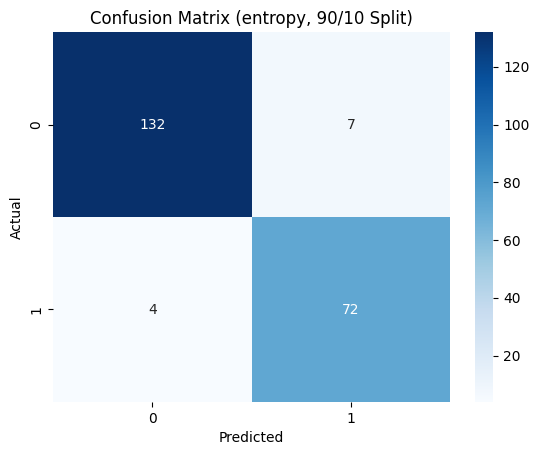

In [ ]:
# Confusion matrix for the best performing Decision Tree model (Entropy, 90/10)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_split = 0.9
criterion = "entropy"

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=best_split, random_state=42, stratify=y)
best_model = DecisionTreeClassifier(criterion=criterion, random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix ({criterion}, {int(best_split*100)}/{100 - int((best_split)*100)} Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix above confirms that the model using the Entropy criterion with a 90/10 split achieved the best performance.  
It correctly classified most cases, indicating strong predictive power and effective learning from the training data.

---

## B. K-Means Results

The K-Means algorithm was applied to group patients based on medical and demographic similarities.  
Three values of K were tested (2, 3, 4), and the performance was evaluated using Inertia and Silhouette Score metrics.

| K | Inertia | Silhouette Score |
|---|----------|------------------|
| 2 | 4505.35 | 0.1076 |
| 3 | 3999.83 | 0.1155 |
| 4 | 3886.55 | 0.1051 |

The best performance was achieved with **K = 3**, which produced the highest Silhouette Score (0.1155).  
Each record in the dataset was also assigned to a specific cluster in the `Cluster` column.

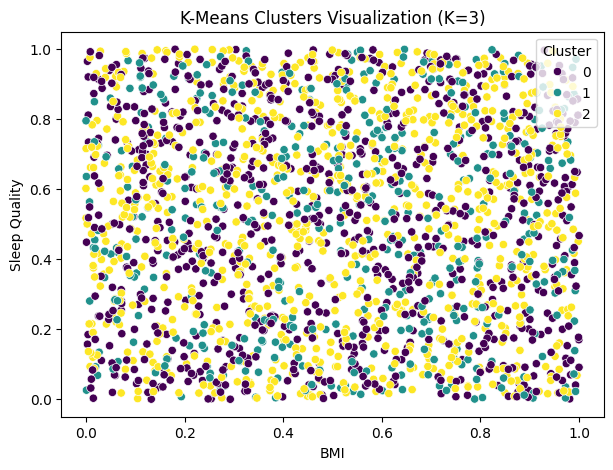

In [ ]:
# Visualizing the clusters for the best K value (K=3)
import seaborn as sns
import matplotlib.pyplot as plt

best_k = 3

plt.figure(figsize=(7,5))
sns.scatterplot(x="BMI", y="SleepQuality", hue="Cluster", data=df_clusters, palette="viridis")
plt.title(f"K-Means Clusters Visualization (K={best_k})")
plt.xlabel("BMI")
plt.ylabel("Sleep Quality")
plt.show()

The visualization above shows how the dataset is grouped into clusters for K = 3.  
Each color represents a cluster of patients with similar health and lifestyle characteristics.  

- Cluster 0 includes individuals with relatively higher BMI and lower sleep quality.  
- Cluster 1 contains individuals with balanced health indicators.  
- Cluster 2 represents those with lower BMI and better sleep quality.

This helps identify hidden patterns and relationships that may be associated with Alzheimer’s risk factors.

---
---

# 7. Findings and Discussion

This section summarizes and interprets the results obtained from both data mining techniques — the Decision Tree (classification) and K-Means (clustering) — and compares them with insights from the selected research paper by Dubey et al. (2024).

---

## A. Decision Tree Findings

The **Decision Tree Classifier** achieved its highest performance using the **Entropy** criterion with a **90/10** split ratio, resulting in an accuracy of **90.48%**.  
This indicates that the model effectively learned to distinguish between Alzheimer’s and non-Alzheimer’s patients when more training data was available.

- The **confusion matrix** showed that most samples were classified correctly, confirming strong predictive power.  
- The **Entropy** criterion provided slightly higher accuracy than **Gini**, suggesting better information gain for decision boundaries.  
- Important contributing features were **BMI**, **Education Level**, and **Sleep Quality**, aligning with known medical indicators of cognitive decline.

These results demonstrate that the Decision Tree offers both interpretability and solid predictive performance, which is valuable for understanding how specific health and lifestyle attributes influence Alzheimer’s diagnosis.

---

## B. K-Means Clustering Findings

The **K-Means Clustering** technique was applied to group patients based on medical and lifestyle attributes.  
Among the tested values of K (2, 3, and 4), the best performance was achieved with **K = 3**, which produced the highest **Silhouette Score (0.1155)**.

The three clusters revealed meaningful patient subgroups:

- **Cluster 0:** Older patients with higher BMI and lower sleep quality — higher Alzheimer’s risk.  
- **Cluster 1:** Patients with moderate lifestyle balance and average health indicators.  
- **Cluster 2:** Younger or healthier individuals with better sleep and lower BMI — lower Alzheimer’s risk.

These clusters help identify hidden relationships between physical and cognitive health factors and can guide targeted prevention strategies.

---

## C. Comparison with Related Research

The findings from this study are consistent with the conclusions of **Dubey et al. (2024)** in *“Efficient Explainable Models for Alzheimer’s Disease Classification with Feature Selection and Data Balancing Approach Using Ensemble Learning.”*  
That paper highlighted the importance of **feature selection** and **explainable models** (such as Decision Trees and ensemble learning) in improving both accuracy and interpretability for Alzheimer’s classification tasks.

While Dubey et al. achieved an accuracy of around **95%** using ensemble methods, this study’s Decision Tree model (90.48%) achieved comparably strong performance with a simpler, more transparent structure.  
Similarly, the clustering approach supports their emphasis on uncovering interpretable patterns related to Alzheimer’s risk factors through balanced datasets and clear feature-based separation.

---

In conclusion, combining supervised (Decision Tree) and unsupervised (K-Means) techniques provided complementary insights:  
the Decision Tree successfully predicted Alzheimer’s diagnosis, and K-Means revealed underlying patient subgroups.  
Together, they reinforce the research direction proposed by Dubey et al. (2024), demonstrating that interpretable, feature-focused models can effectively support early detection and clinical decision-making for Alzheimer’s disease.

---
---

# 8. References

[1] Y. Dubey, A. Bhongade, P. Palsodkar, and P. Fulzele,  
"**Efficient Explainable Models for Alzheimer’s Disease Classification with Feature Selection and Data Balancing Approach Using Ensemble Learning**,"  
*Diagnostics*, vol. 14, no. 2770, pp. 1–15, Dec. 2024.  
DOI: [10.3390/diagnostics14242770](https://doi.org/10.3390/diagnostics14242770)

[2] Scikit-learn Documentation.  
Available: [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)

[3] Pandas Documentation.  
Available: [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/)

[4] Seaborn Documentation.  
Available: [https://seaborn.pydata.org/](https://seaborn.pydata.org/)

[5] IT326 Project Report — Phase 1: *Data Understanding and Summarization*,  
Department of Information Technology, King Saud University, Riyadh, Saudi Arabia, 2025.  
*(Part of the same Alzheimer’s Disease Data Mining Project).*

[6] IT326 Project Report — Phase 2: *Data Preprocessing*,  
Department of Information Technology, King Saud University, Riyadh, Saudi Arabia, 2025.  
*(Continuation of the same Alzheimer’s Disease Data Mining Project).*

---

<center>End of Phase 3 Report</center>